# Project Business Statistics: E-news Express


## Define Problem Statement and Objectives

Business Context

The advent of e-news, or electronic news, portals has offered us a great opportunity to quickly get updates on the day-to-day events occurring globally. The information on these portals is retrieved electronically from online databases, processed using a variety of software, and then transmitted to the users. There are multiple advantages of transmitting new electronically, like faster access to the content and the ability to utilize different technologies such as audio, graphics, video, and other interactive elements that are either not being used or aren’t common yet in traditional newspapers.

E-news Express, an online news portal, aims to expand its business by acquiring new subscribers. With every visitor to the website taking certain actions based on their interest, the company plans to analyze these actions to understand user interests and determine how to drive better engagement. The executives at E-news Express are of the opinion that there has been a decline in new monthly subscribers compared to the past year because the current webpage is not designed well enough in terms of the outline & recommended content to keep customers engaged long enough to make a decision to subscribe.

[Companies often analyze user responses to two variants of a product to decide which of the two variants is more effective. This experimental technique, known as A/B testing, is used to determine whether a new feature attracts users based on a chosen metric.]

Objective

The design team of the company has researched and created a new landing page that has a new outline & more relevant content shown compared to the old page. In order to test the effectiveness of the new landing page in gathering new subscribers, the Data Science team conducted an experiment by randomly selecting 100 users and dividing them equally into two groups. The existing landing page was served to the first group (control group) and the new landing page to the second group (treatment group). Data regarding the interaction of users in both groups with the two versions of the landing page was collected. Being a data scientist in E-news Express, you have been asked to explore the data and perform a statistical analysis (at a significance level of 5%) to determine the effectiveness of the new landing page in gathering new subscribers for the news portal by answering the following questions:

* Do the users spend more time on the new landing page than on the existing landing page?

* Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

* Does the converted status depend on the preferred language?

* Is the time spent on the new page the same for the different language users?

## Import all the necessary libraries

In [112]:
# Installing the libraries with the specified version.
!pip install numpy==1.26.4 pandas==2.2.2 matplotlib==3.8.0 seaborn==0.13.2 scipy==1.11.4 -q --user


In [113]:
import warnings # To suppress some warnings

# Suppress the specific FutureWarning
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [114]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Library to help with statistical analysis
import scipy.stats as stats

## Reading the Data into a DataFrame

In [115]:
enews = pd.read_csv('/content/abtest.csv')


## Explore the dataset and extract insights using Exploratory Data Analysis

- Data Overview
  - Viewing the first and last few rows of the dataset
  - Checking the shape of the dataset
  - Getting the statistical summary for the variables
- Check for missing values
- Check for duplicates

In [116]:
# checking the first and last few rows of the dataset
enews.head()


,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
0,546592,control,old,3.48,no,Spanish
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
3,546567,control,old,3.02,no,French
4,546459,treatment,new,4.75,yes,Spanish


In [117]:
enews.tail()

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
95,546446,treatment,new,5.15,no,Spanish
96,546544,control,old,6.52,yes,English
97,546472,treatment,new,7.07,yes,Spanish
98,546481,treatment,new,6.20,yes,Spanish
99,546483,treatment,new,5.86,yes,English


* The only numerical column other than user_id is time_spent_on_the_page.

* The values for the other columns are all of categorical in nature and seem appropriate.

In [118]:
# checking the shape of the data
print(f'The data has {enews.shape[0]} rows and {enews.shape[1]} columns.')

The data has 100 rows and 6 columns.


In [119]:
# checking the data types of the columns for the dataset
enews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   user_id                 100 non-null    int64  
 1   group                   100 non-null    object 
 2   landing_page            100 non-null    object 
 3   time_spent_on_the_page  100 non-null    float64
 4   converted               100 non-null    object 
 5   language_preferred      100 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 4.8+ KB


* There are 2 numerical columns and 4 object columns.

* All the columns appear to be of proper types.

* There are no missing values in each of the columns. We can confirm it with a code.

In [120]:
# let's check for missing values in the data
enews.isnull().sum()

,0
user_id,0
group,0
landing_page,0
time_spent_on_the_page,0
converted,0
language_preferred,0


There are no missing values in the data as above.

Let's check for duplicate values.


In [121]:
# checking duplicate values.
enews.duplicated().sum()

0

There are no duplicate values in the data.

Let's check the statistical summary of the data.

In [122]:
enews.describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,100.0,546517.0000,52.295779,546443.00,546467.75,546492.500,546567.2500,546592.00
time_spent_on_the_page,100.0,5.3778,2.378166,0.19,3.88,5.415,7.0225,10.71


* The mean is a little less than the median, which suggests that the data is slightly left skewed.

* There is a huge difference between the minimum value and the 25% percentile of the data which indicates there might be outliers present in this column.

### Univariate Analysis

<Axes: xlabel='time_spent_on_the_page', ylabel='Count'>

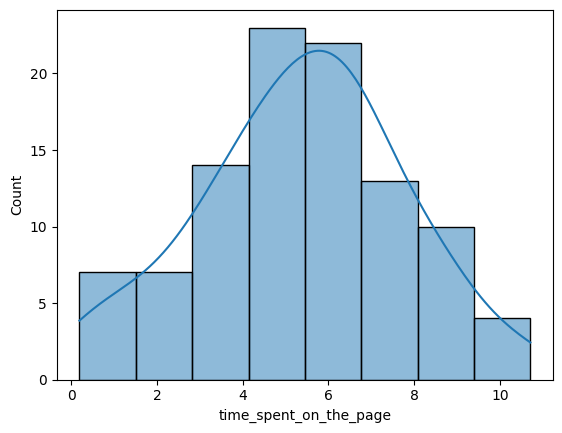

In [123]:
sns.histplot(data=enews, x='time_spent_on_the_page', kde=True)

The histogram graph is almost bell-shaped and slightly left skewed.

<Axes: xlabel='time_spent_on_the_page'>

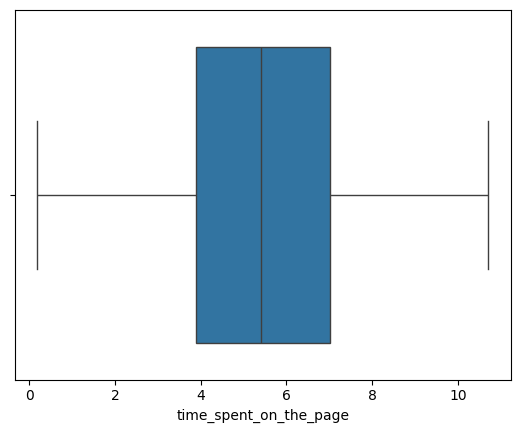

In [124]:
# let's visualize the data using a boxplot.
sns.boxplot(data=enews, x='time_spent_on_the_page')

The box plot shows no outliers.

# Let's explore the categorical variables now.

Bar Charts can be used to explore the distribution of categorical values.

<Axes: xlabel='group', ylabel='count'>

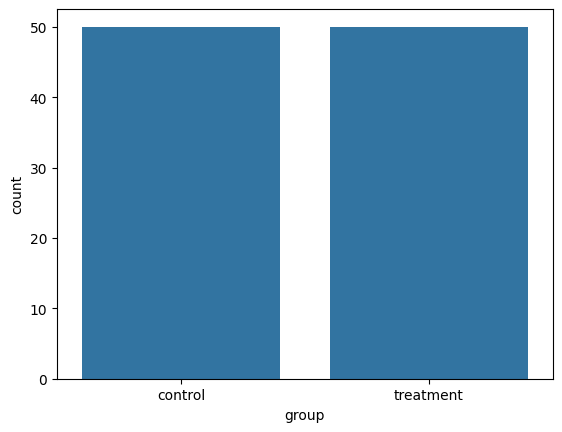

In [125]:
# let's visualize the distribution of group, landing_page, converted, and language_preferred using countplot.
sns.countplot(data=enews, x='group')

As expected, the number of control group is the same as that of treatment group.

<Axes: xlabel='landing_page', ylabel='count'>

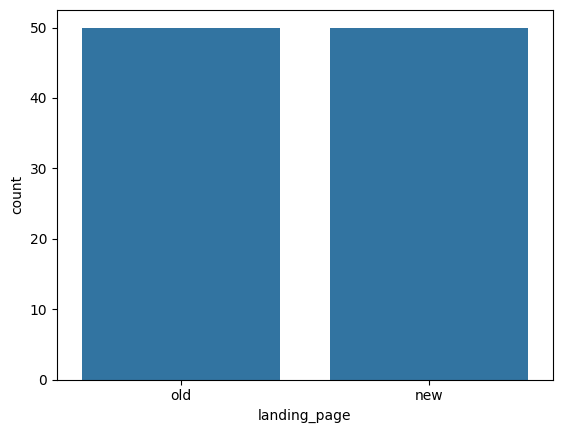

In [126]:
sns.countplot(data=enews, x='landing_page')

As expected, the number of landing_page is the same between old and new.

<Axes: xlabel='converted', ylabel='count'>

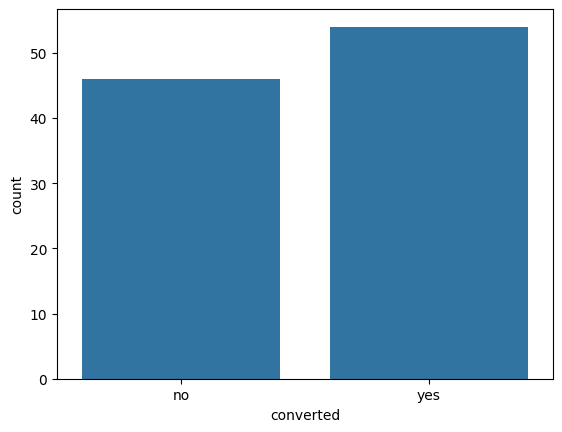

In [127]:
sns.countplot(data=enews, x='converted')

There are more converted than not converted.

<Axes: xlabel='language_preferred', ylabel='count'>

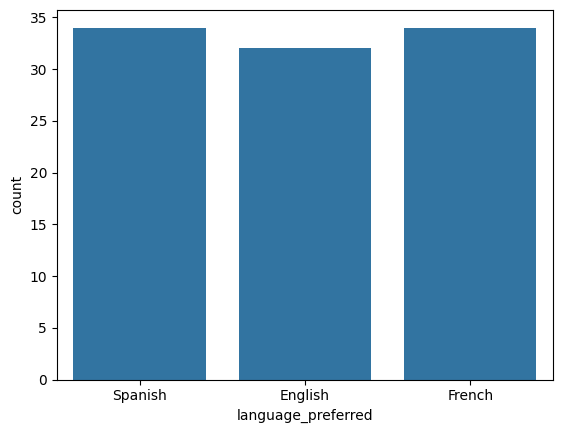

In [128]:
sns.countplot(data=enews, x='language_preferred')

Spanish and Frensh are the same and a little more than English.

### Bivariate Analysis

Let's check whether there is any significant effect of the categorical variables on the time_spent_on_the_page.

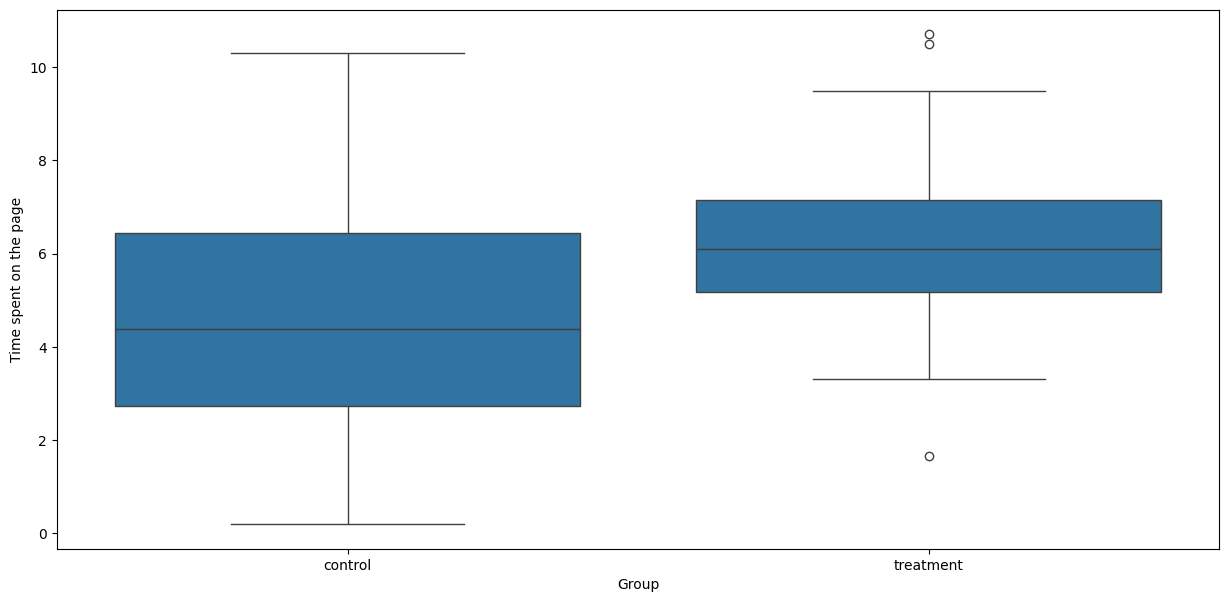

In [129]:
# time_spent_on_the_page by group
plt.figure(figsize=(15, 7))
sns.boxplot(data=enews, x='group', y='time_spent_on_the_page')
plt.ylabel('Time spent on the page')
plt.xlabel('Group')
plt.show()

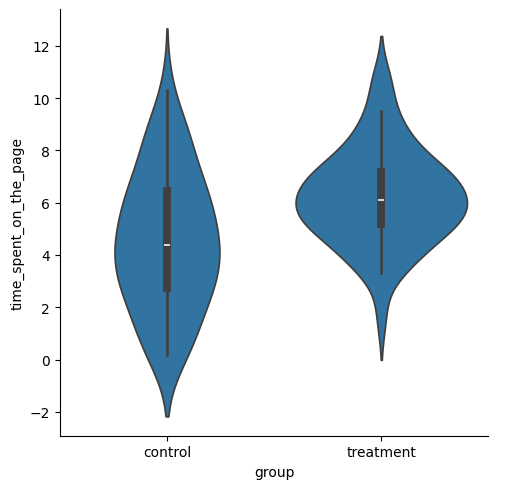

In [130]:
# dispersion of time_spent_on_the_page across each group
sns.catplot(data=enews, x='group', y='time_spent_on_the_page', kind='violin')
plt.show()

* There is a clear difference in the time spent on the page across different groups.

* The treatment group spent more time on the page than the control group.

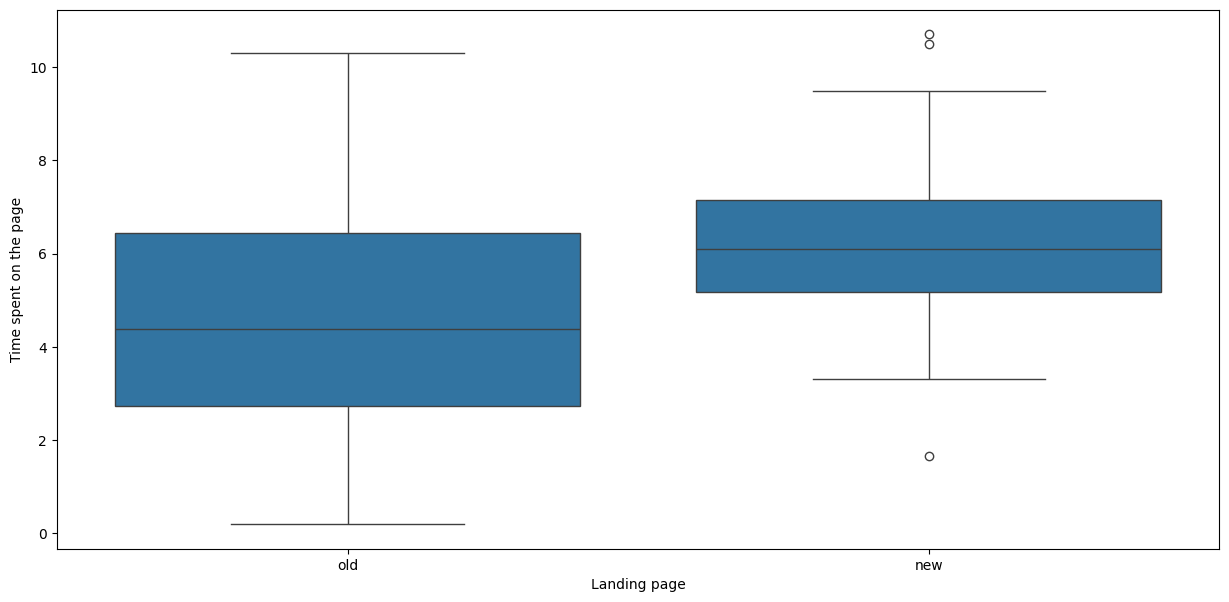

In [131]:
# time spent on the page across different landing pages.
plt.figure(figsize=(15, 7))
sns.boxplot(data=enews, x='landing_page', y='time_spent_on_the_page')
plt.ylabel('Time spent on the page')
plt.xlabel('Landing page')
plt.show()

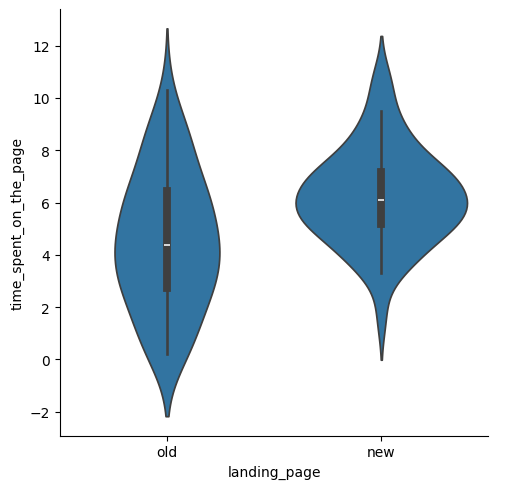

In [132]:
sns.catplot(data=enews, x='landing_page', y='time_spent_on_the_page', kind='violin')
plt.show()

* There is a clear difference in the time spent on the page across different landing pages.

* The group shown the new landing page spent more time on the page than the group shown the old landing page.

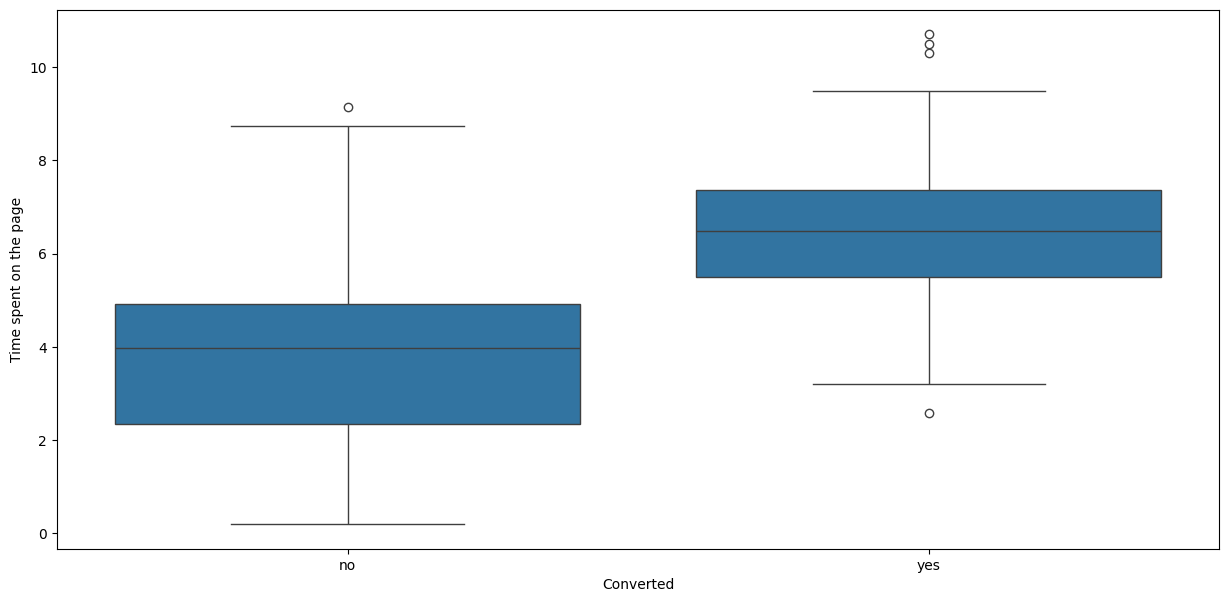

In [133]:
# time spent on the page across converted category
plt.figure(figsize=(15, 7))
sns.boxplot(data=enews, x='converted', y='time_spent_on_the_page')
plt.ylabel('Time spent on the page')
plt.xlabel('Converted')
plt.show()

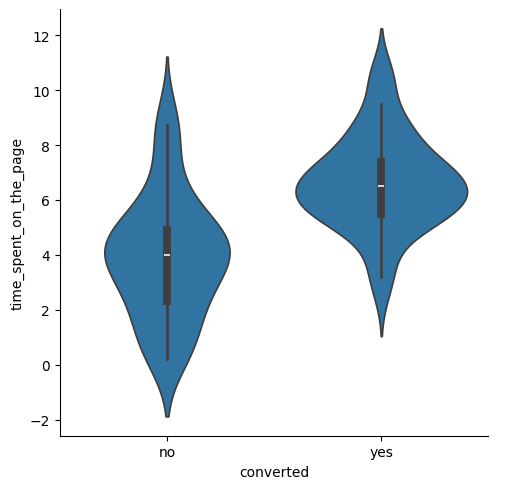

In [134]:
sns.catplot(data=enews, x='converted', y='time_spent_on_the_page', kind='violin')
plt.show()

* There is a clear difference in the time spent on the page across converted category.

* The converted group spent more time on the page than the unconverted group.

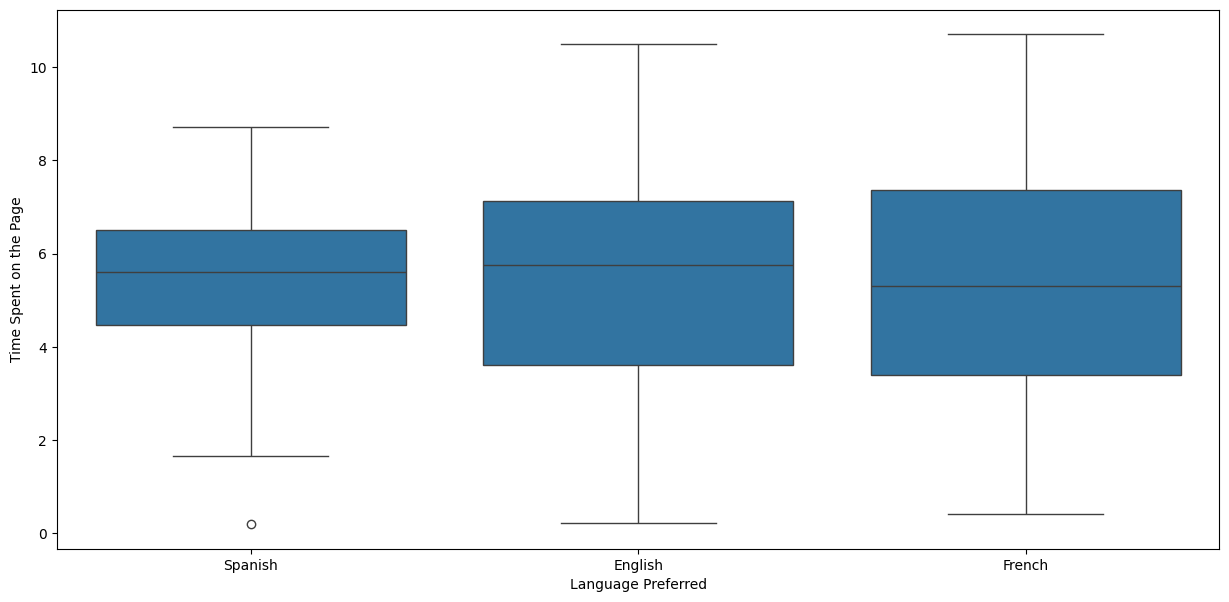

In [135]:
# time spent on the page across language preference.
plt.figure(figsize=(15, 7))
sns.boxplot(data=enews, x='language_preferred', y='time_spent_on_the_page')
plt.ylabel('Time Spent on the Page')
plt.xlabel('Language Preferred')
plt.show()

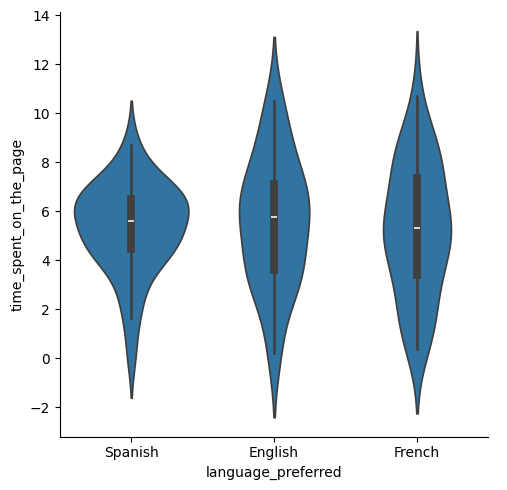

In [136]:
sns.catplot(data=enews, x='language_preferred', y='time_spent_on_the_page', kind='violin')
plt.show()

* The average time spent on the page is almost the same among groups with different language preference.

* English and French groups are similar to each other but have greater variances than Spanish group.

# Multivariate Analysis
Let's explore the distribution of time spent on the page with multiple categorical variables.

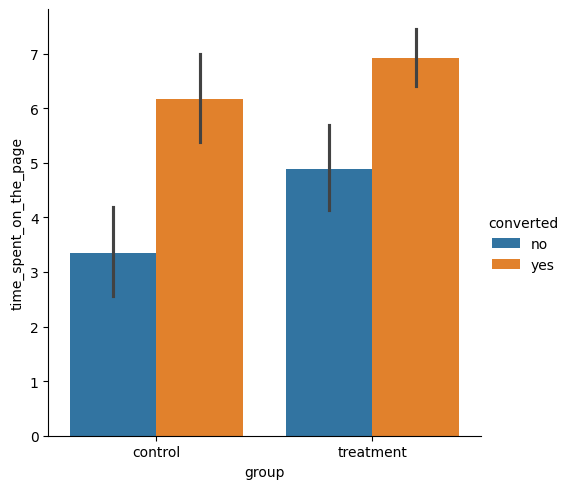

In [137]:
# time spent on the page across different group and converted categories.
sns.catplot(data=enews, x='group', y='time_spent_on_the_page', hue='converted', kind='bar')
plt.show()

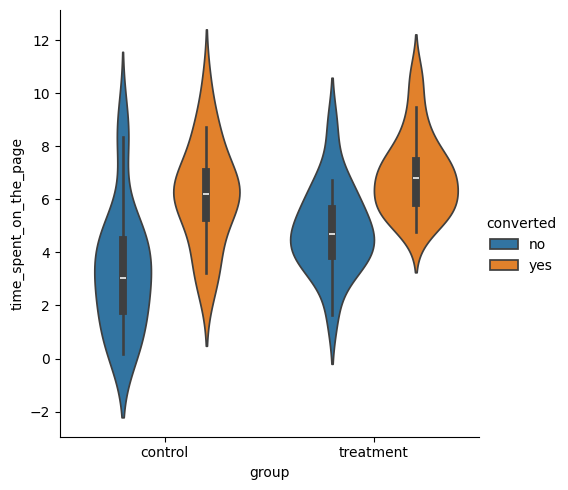

In [138]:
sns.catplot(data=enews, x='group', y='time_spent_on_the_page', hue='converted', kind='violin')
plt.show()

* In both control and treatment groups, converted group spent more time on the page than unconverted group.

* In both converted and unconverted groups, treatment group spent more time on the page than control group.

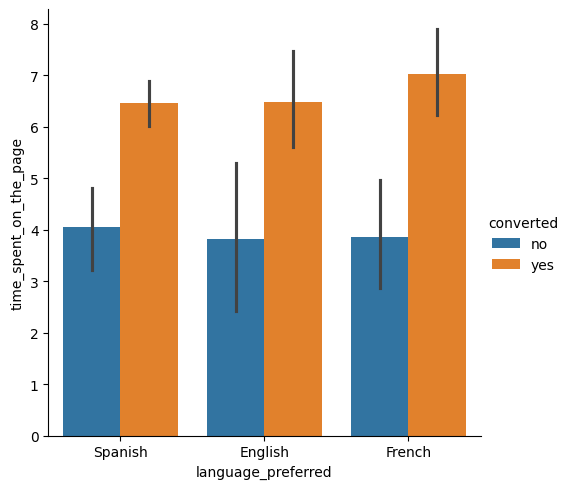

In [139]:
# time spent on the page across language preference and converted
sns.catplot(data=enews, x='language_preferred', y='time_spent_on_the_page', hue='converted', kind='bar')
plt.show()

<Figure size 1500x700 with 0 Axes>

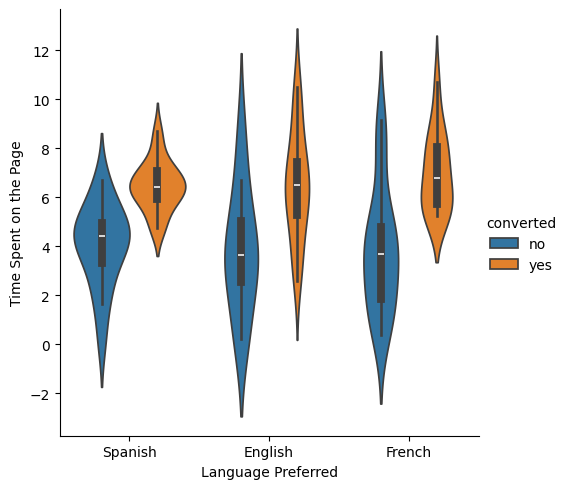

In [140]:
plt.figure(figsize=(15, 7))
sns.catplot(data=enews, x='language_preferred', y='time_spent_on_the_page', hue='converted', kind='violin')
plt.ylabel('Time Spent on the Page')
plt.xlabel('Language Preferred')
plt.show()

* There are not much differences in time spent on the page among different language groups who were not converted.

* Among converted groups, French group spent more time than Spanish or English groups.

## 1. Do the users spend more time on the new landing page than the existing landing page?

### Perform Visual Analysis

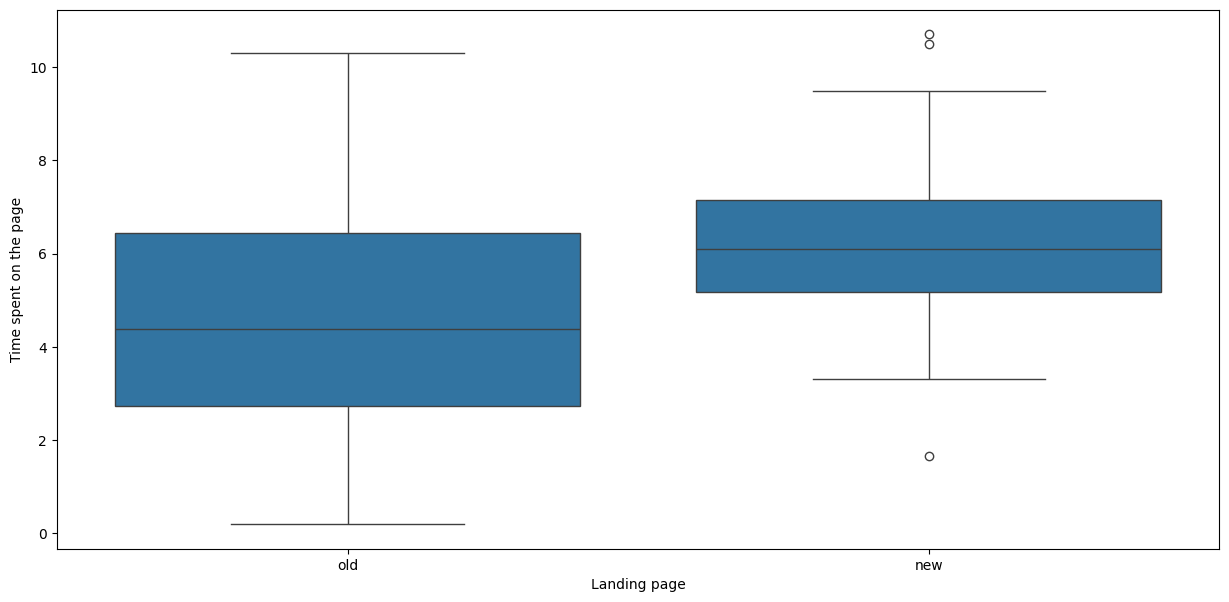

In [141]:
# time spent on the page across different landing pages.
plt.figure(figsize=(15, 7))
sns.boxplot(data=enews, x='landing_page', y='time_spent_on_the_page')
plt.ylabel('Time spent on the page')
plt.xlabel('Landing page')
plt.show()

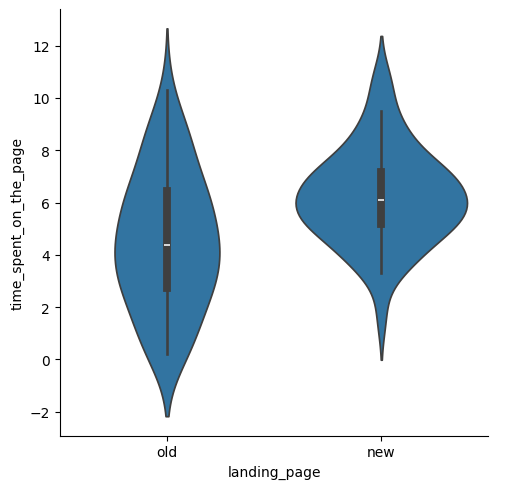

In [142]:
sns.catplot(data=enews, x='landing_page', y='time_spent_on_the_page', kind='violin')
plt.show()

* As discussed above, users spend more time on the new landing page than the existing landing page.

### Step 1: Define the null and alternate hypotheses

Null hypothesis: Users spend the same time on the new landing page as the existing page.

Alternative hypothesis: Users spend more time on the new landing page than the existing page.

Or, we express the tests via formula: the null hypothesis

>$H_0:\mu_1=\mu_2$

against the alternate hypothesis

>$H_a:\mu_1>\mu_2$

### Step 2: Select Appropriate test

As we are interested in testing if the mean from two different samples (new landing page and existing landing page group) is the same or not and the population standard deviation is not known, 2 sample independent t-test could be used.

Let's test whether the T-test assumptions are satisfied or not.

* Continuous data - Yes, the time is measured on a continuous scale.

* Normally distributed populations - Yes, we are informed that the populations are assumed to be normal.

* Independent populations - As we are taking samples for two different type of users from control and treatment group (i.e., A/B Test), the two samples are from two independent populations.

* Equal population standard deviations - As the sample standard deviations are 'almost' equal (see below) although existing landing page has greater variance (2.58 vs. 1.82), the population standard deviations may be assumed to be equal.

* Random sampling from the population - Yes, we are informed that the collected sample is a simple random sample.

Voila! We can use two sample T-test for this problem.

In [143]:
# let's get some statistical summary/overview of the subset of the data with landing page.
enews[enews['landing_page'] == 'new'].describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,50.0,546467.5000,14.577380,546443.00,546455.250,546467.500,546479.75,546492.00
time_spent_on_the_page,50.0,6.2232,1.817031,1.65,5.175,6.105,7.16,10.71


In [144]:
enews[enews['landing_page'] == 'old'].describe().T

,count,mean,std,min,25%,50%,75%,max
user_id,50.0,546566.5000,17.677670,546493.00,546555.25,546567.50,546579.7500,546592.0
time_spent_on_the_page,50.0,4.5324,2.581975,0.19,2.72,4.38,6.4425,10.3


### Step 3: Decide the significance level

As required in the objective, we will set the level of significance $\alpha$ at 0.05.

### Step 4: Collect and prepare data

The data have been collected and prepared for the test in the above.

### Step 5: Calculate the p-value

In [146]:
# import the required function
from scipy.stats import ttest_ind

# find the p-value
test_stat, p_value = ttest_ind(enews[enews['landing_page'] == 'new']['time_spent_on_the_page'],
                               enews[enews['landing_page'] == 'old']['time_spent_on_the_page'], equal_var=True, alternative='greater')
print(f'The p-value is {p_value}.')

The p-value is 0.0001316123528095005.


### Step 6: Compare the p-value with $\alpha$

In [147]:
# print the conclusion based on the p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value 0.0001316123528095005 is less than the level of significance, we reject the null hypothesis.


### Step 7:  Draw inference

* Based on the sample data, users landing on the new page spend more time than those landing on the existing page (average time in minutes 6.2 vs. 4.5).

* There was enough statistical evidence to conclude that users landing on the new page spend more time than those landing on the existing page.

* The size of the sample can be increased to make the conclusion from the statistical test more reliable.

**A similar approach can be followed to answer the other questions.**

## 2. Is the conversion rate (the proportion of users who visit the landing page and get converted) for the new page greater than the conversion rate for the old page?

In [148]:
# before writing and testing our hypotheses, let's obtain the sample, creating a subset for conversion rate across different landing pages
enews.groupby('landing_page')['converted'].value_counts()

landing_page  converted
new           yes          33
              no           17
old           no           29
              yes          21
Name: count, dtype: int64

In [149]:
# assign values to sample variables

# number of users landing on new landing page
new = enews.landing_page.value_counts()['new']

# number of users landing on old landing page
old = enews.landing_page.value_counts()['old']

print('The total number of users landing on new and old landing pages are {0} and {1}, respectively'.format(new, old))

# number of users landing on new landing page converted
new_converted = enews[enews.landing_page == 'new'].converted.value_counts()['yes']

# number of users landing on old landing page converted
old_converted = enews[enews.landing_page == 'old'].converted.value_counts()['yes']

print('The number of users landing on new and old landing pages converted are {0} and {1}, respectively'.format(new_converted, old_converted))

The total number of users landing on new and old landing pages are 50 and 50, respectively
The number of users landing on new and old landing pages converted are 33 and 21, respectively


In [150]:
print(f'The proportions of conversion in new and old landing pages are {round(new_converted/new,2)}, {round(old_converted/old,2)} respectively')

The proportions of conversion in new and old landing pages are 0.66, 0.42 respectively


* The proportions in the sample are different. Let's conduct the test to see if this difference is significant.

# Hypothesis Testing

## Step 1: Define null and alternative hypotheses

Let $p_1,p_2$ be the proportions of conversion in landing on new page and landing on old page, respectively.

We will test the null hypothesis

>$H_0:p_1 <= p_2$

against the alternate hypothesis

>$H_a:p_1 \gt p_2$

## Step 2: Select Appropriate test

This is a case of a two-tailed test for the two sample z-test, through which we can compare the sample proportions from two population.

Let's test whether the Z-test assumptions are satisfied or not.

* Binomially distributed population - Yes, a user is converted or not converted.

* Randomly sampling from the population - Yes, we are informed that the collected sample is a simple random sample.

* Can the binomail distribution approximate to normal distribution - Yes. For binomial data, CLT works slower than usual. The standard thing is to check whether np and n(1-p) are greater than or equal to 10. Here, n and p refer to the sample size and sample proportion, respectively.

n1p1 = 50*(33/50) = 33 >= 10

n1(1-p1) = 50*((50-33)/50) = 17 >= 10

n2p2 = 50*(21/50) = 21 >= 10

n2(1-p2) = 50*((50-21)/50) = 29 >= 10

We can use the Z-test.

## Step 3: Decide the significance level

As required in the objective, we will set the significance level α at 0.05.

## Step 4: Collect and prepare data

The data have been collected and prepared in the above.

## Step 5: Calculate the p-value

This test uses the proportions_ztest() function for comparing two proportions.

In [151]:
# import the required function
from statsmodels.stats.proportion import proportions_ztest

# find the p-value
test_stat, p_value = proportions_ztest([new_converted, old_converted], [new, old], alternative='two-sided')

# print the p-value
print(f'The p-value is {p_value}.')

The p-value is 0.016052616408112556.


## Step 6: Compare the p-value with α

In [152]:
# print the conclusion based on p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')

As the p-value 0.016052616408112556 is less than the level of significance, we reject the null hypothesis.


## Step 7:  Draw inference

Since the p-value is < 0.05, we reject the null hypothesis. Hence, we have enough statistical evidence to conclude that the proportion of conversion in the population for the new landing page is greater than the proportion of conversion in the population for the old landing page.

## Insight

The conversion rate (the proportion of users who visit the landing page and get converted) for the new page is greater than the conversion rate for the old landing page.

## 3. Is the conversion and preferred language are independent or related?

In [153]:
# let's import the additional necessary libraries
from scipy.stats import chi2_contingency   # For Chi-Square test

## Step 1: Define null and alternative hypotheses

$H_0:$ Conversion is independent of preferred language

$H_a:$ Conversion is NOT independent of preferred language

## Step 2: Select Appropriate test

The formulated hypotheses can be tested using a Chi-square test of independence of attributes, concerning the two categorical variables, conversion (yes/no) and language preference (Spanish, English, and French).

## Step 3: Decide the significance level
As required in the objective, we select α= 0.05.

## Step 4: Collect and prepare data
To perform the Chi-squared test of independance we need to create the contingency table. A contingency table is a tabular representation of categorical data. A contingency table shows the number of observations for combinations of values between two categorical variables, say X and Y. Each cell in the contingency table represents a combination of X-Y values.

The pandas crosstab() function is used to create a contingency table between two categorical variables from a dataframe.

In [154]:
# create the contingency table showing the distribution of the two categorical variables
contingency_table = pd.crosstab(enews['converted'], enews['language_preferred'])
contingency_table

language_preferred,English,French,Spanish
converted,,,
no,11,19,16
yes,21,15,18


We have created a two-by-three contingency table, with the counts of 'converted' (Yes or No) in the rows and the counts of 'language_preferred' (English, French, or Spanish) in the columns.

## Step 5: Calculate the p-value


In [155]:
# use chi2_contingency() function to find the p-value
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

# print the p-value
print(f'The p-value is {p_value}.')

The p-value is 0.21298887487543447.


## Step 6: Compare the p-value with  α

In [156]:
# print the conclusion based on the p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
    print('Conversion is NOT independent of preferred language.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')
    print('Conversion is independent of preferred language.')

As the p-value 0.21298887487543447 is greater than the level of significance, we fail to reject the null hypothesis.
Conversion is independent of preferred language.


## Step 7:  Draw inference
Since the p-value is > 0.05, we fail to reject the null hypothesis. Hence, we do not have enough statistical evidence to conclude that conversion is NOT independent of preferred language.

## Insight
Conversion and preferred language are independent and NOT related.

## 4. Is the time spent on the new page same for the different language users?

## Step 1: Define the null and alternate hypotheses
Let's write the null and alternative hypothesis

Let μ1, μ2, μ3 be the means of time spent on the new landing page for English, French, and Spanish, respectively.

We will test the null hypothesis

H0: μ1 = μ2 = μ3

against the alternative hypothesis

Ha: At least one language is different from the rest.

## Step 2: Select Appropriate test

Before we select the test, the normality and equality of variance assumptions need to be checked.

For testing of normality, Shapiro-Wilk’s test is applied to the response variable.

For equality of variance, Levene test is applied to the response variable.

### Shapiro-Wilk’s test
We will test the null hypothesis

>$H_0:$ Time spent on the new landing page follows a normal distribution against

against the alternative hypothesis

>$H_a:$ Time spent on the new landing page does not follow a normal distribution

The shapiro() function of Scipy will be used to compute the test statistic and p-value.

In [162]:
# Assumption 1: Normality
# import the required function
from scipy.stats import shapiro

# assign a subset of the dataset for time spent on the new landing page to a variable
enews_new = enews[enews['landing_page'] == 'new']
enews_new

,user_id,group,landing_page,time_spent_on_the_page,converted,language_preferred
1,546468,treatment,new,7.13,yes,English
2,546462,treatment,new,4.40,no,Spanish
4,546459,treatment,new,4.75,yes,Spanish
6,546448,treatment,new,5.25,yes,French
8,546461,treatment,new,10.71,yes,French
12,546491,treatment,new,5.86,yes,Spanish
13,546478,treatment,new,6.03,yes,French
15,546466,treatment,new,6.27,yes,Spanish
16,546443,treatment,new,8.73,no,English
22,546450,treatment,new,3.65,no,English


In [163]:
# find the p-value
test_stat, p_value = shapiro(enews_new['time_spent_on_the_page'])
print(f'The p-value is {p_value}.')

The p-value is 0.8040040364746845.


Since p-value of the test is very large, we fail to reject the null hypothesis that the response follows the normal distribution.

### Levene’s test
We will test the null hypothesis

>$H_0$: All the population variances are equal

against the alternative hypothesis

>$H_a$: At least one variance is different from the rest

The levene() function of scipy will be used to compute the test statistic and p-value.

In [164]:
# Assumption 2: Homogeneity of Variance
# import the required function
from scipy.stats import levene

test_stat, p_value = levene(enews_new[enews_new['language_preferred'] == 'English']['time_spent_on_the_page'],
                            enews_new[enews_new['language_preferred'] == 'French']['time_spent_on_the_page'],
                            enews_new[enews_new['language_preferred'] == 'Spanish']['time_spent_on_the_page'])
print(f'The p-value is {p_value}.')

The p-value is 0.46711357711340173.


Since the p-value is large, we fail to reject the null hypothesis of homogeneity of variances.

Let's test whether the assumptions are satisfied or not

* The populations are normally distributed - Yes, the normality assumption is verified using the Shapiro-Wilk’s test.
* Samples are independent simple random samples - Yes, we are informed that the collected sample is a simple random sample.
* Population variances are equal - Yes, the homogeneity of variance assumption is verified using the Levene's test.

## Step 3: Decide the significance level
As required in the objective, we select α= 0.05.

## Step 4: Collect and prepare data

The data have been collected and prepared in the above steps.

## Step 5: Calculate the p-value

The f_oneway() function of scipy will be used to compute the test statistic and p-value.

In [167]:
# import the required library
from scipy.stats import f_oneway

# perform the one-way anova test
test_stat, p_value = f_oneway(enews_new.loc[enews_new['language_preferred'] == 'English', 'time_spent_on_the_page'],
                              enews_new.loc[enews_new['language_preferred'] == 'French', 'time_spent_on_the_page'],
                              enews_new.loc[enews_new['language_preferred'] == 'Spanish', 'time_spent_on_the_page'])

print(f'The p-value is {p_value}.')

The p-value is 0.43204138694325955.


## Step 6: Compare the p-value with  α

In [168]:
# print the conclusion based on the p-value
if p_value < 0.05:
    print(f'As the p-value {p_value} is less than the level of significance, we reject the null hypothesis.')
else:
    print(f'As the p-value {p_value} is greater than the level of significance, we fail to reject the null hypothesis.')


As the p-value 0.43204138694325955 is greater than the level of significance, we fail to reject the null hypothesis.


## Step 7:  Draw inference

### Insight
As the p-value is much greater than the significance level, we cannot reject the null hypothesis. Hence, we do not have enough statistical significance to conclude that one language is different from the rest at 5% significance level. Therefore, based on the sample tested, the time spent on the new page is the same for the different language users.


## Conclusion and Business Recommendations

The data exploration and statistical analysess (at a significance level of 5%) performed as above appear to confirm the effectiveness of the new landing page in gathering new subscribers for the news portal.

### Summary of Findings

* Based on the sample data, users landing on the new page spend more time than those landing on the existing page.

* There was enough statistical evidence to conclude that users landing on the new page spend more time than those landing on the existing page.

* The conversion rate (the proportion of users who visit the landing page and get converted) for the new page is greater than the conversion rate for the old landing page.

* Conversion and preferred language are independent and NOT related.

* The time spent on the new page is the same for the different language users.

* The sample size can be increased to further validate the findings and make the statistical evidence more robust. This will also help identify any potential nuances or subgroups that may respond differently.

### Business Recommendations

1. Implement the New Landing Page:

>Since the new landing page has been statistically proven effective in increasing both time spent and conversion rates, it should be fully rolled out.

2. Enhance User Engagement on the New Page:

>Capitalize the increased user time on the new landing page by adding additional contents customized for news preferences of users.

3. Explore Conversion Drivers Beyond Language:

>Since conversion is independent of language, explore other factors that may could increase conversion rates and optimize accordingly.



___